# Normalize Total Gradient (NTG) - From the Scratch (v1)

### Importamos las librerías necesarias para calcular el NTG

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution
from scipy.optimize import minimize_scalar

### Cargamos las imágenes

In [2]:
ti = 1 # Definimos el total de imagenes a trabajar

## -- Inicialización de listas para almacenar las imagenes -- ##

img_BGR = []                # Lista de imagenes BGR (formato base)
img_IR = []                 # Lista de imagenes NIR (espectro IR)
img_RGB = []                # Lista de imagenes RGB (conversión para visualización de color apropiada)
img_RGBgray = []            # Lista de imagenes RGB en grayscale (usado para aplicar operaciones)
img_IR_translation = []     # Lista de imagenes NIR con aberraciones (traslación)

## -- Carga de imagenes del dataset y operaciones sobre ellas (aberraciones,conversiones,etc.) -- ## {n:03d}
for n in range(1):
    bgr = cv2.imread(f'/Users/Alex/Documents/Dataset_Vegetation_Final_Version/Sat_images/Photos_2018/GC_019.png')
    ir = cv2.imread(f'/Users/Alex/Documents/Dataset_Vegetation_Final_Version/Additional_data/Infrared_images/Infrared_2018/GC_019_Infrarred.png',cv2.IMREAD_GRAYSCALE)

    # Verificación de carga correcta de imagenes
    if bgr is None or ir is None:
        print(f'Error al cargar la imagen {n}')
        continue

    ## -- Conversiones de formato -- ##
    rgb = cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)          # Conversión de BGR a RGB
    rgb_gray = cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY)    # Conversión de RGB a Grayscale

    
    ## -- ABERRACIÓN - imagen IR desplazada (en x, y o ambas) -- ##
    h_ir, w_ir = ir.shape[:2]                                    # Obtenemos las dimensiones de la imagen

    tras_x = 200                                                 # Pixeles de desplazamiento en x (+ derecha, - izquierda)
    tras_y = 200                                                 # Pixeles de desplazamiento en y (+ abajo, - arriba)
    m_translation = np.float32([[1,0,tras_x],[0,1,tras_y]])      # Matriz de traslación 

    translation_imgIR = cv2.warpAffine(ir,m_translation,(w_ir,h_ir)) # Generamos la imagen con traslación

    

    # -- Guardar la imagenes en sus respectivas listas -- ##
    img_BGR.append(bgr)                            # Agregar las imagenes BGR a la lista
    img_RGB.append(rgb)                            # Agregar las imagenes RGB a la lista
    img_IR.append(ir)                              # Agregar las imagenes NIR a la lista
    img_RGBgray.append(rgb_gray)                   # Agregar las imagenes RGB en grayscale a la lista
    img_IR_translation.append(translation_imgIR)   # Agregar las imagenes NIR con traslación a la lista

In [3]:
def zoom_cv(img_RGB,zoom_factor):
    
    h, w = img_RGB.shape[:2]

    if zoom_factor <= 0 or zoom_factor <= 1:
        return img_RGB

    new_w = int(w/zoom_factor)
    new_h = int(h/zoom_factor)

    x1 = int((w - new_w) / 2)
    y1 = int((h - new_h) / 2)
    x2 = x1 + new_w
    y2 = y1 + new_h

    crop_zoom = img_RGB[y1:y2, x1:x2]

    img_zoom = cv2.resize(crop_zoom,(w,h),interpolation=cv2.INTER_CUBIC)

    return img_zoom 

In [4]:
zoomx2_imgGRAY_list = []
zoomx2_img_list = []
zoom_factor_v0 = 20.00

for n in range(len(img_RGB)):
    zoom_img = zoom_cv(img_RGB[n],zoom_factor_v0)
    gray_zoom = cv2.cvtColor(zoom_img.copy(),cv2.COLOR_RGB2GRAY)

    zoomx2_imgGRAY_list.append(gray_zoom)
    zoomx2_img_list.append(zoom_img)

(982, 1964)


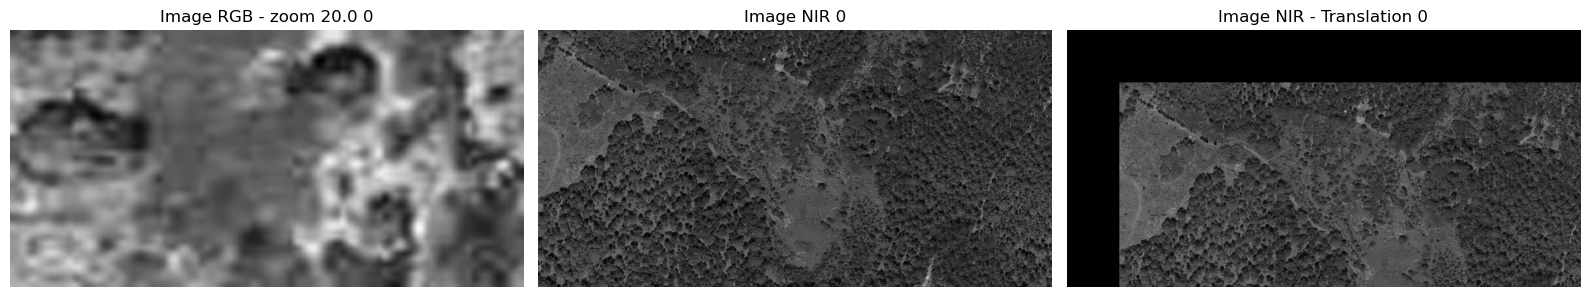

In [5]:
for n in range(len(img_RGB)):
    plt.figure(figsize=(16,14))
    
    plt.subplot(1,3,1)
    plt.title(f"Image RGB - zoom {zoom_factor_v0} {n}")
    plt.imshow(zoomx2_imgGRAY_list[n],cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title(f"Image NIR {n}")
    plt.imshow(img_IR[n],cmap='gray')
    plt.axis('off')
    print(img_RGBgray[n].shape)

    plt.subplot(1,3,3)
    plt.title(f"Image NIR - Translation {n}")
    plt.imshow(img_IR_translation[n],cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

## NTG - Versión I [versión base aproximada al paper de Cheng]

### Step I - Normalización

In [6]:
## === FUNCIÓN DE NORMALIZACIÓN PARA NTG === ##
def normalize_image(img):
    
    img = img.astype(np.float32)    # Conversión del tipo de dato a float de 32 bits

    min_val = np.min(img)           # Valores mínimos de la imagen normalizada
    max_val = np.max(img)           # Valores máximos de la imagen normalizada

    if max_val - min_val < 1e-8:    # Control para evitar divisiones entre 0 y con ello errores
        return np.zeros_like(img)

    norm_img = (img - min_val)/(max_val - min_val)  # Normalizamos la intensidad de la imagen
    
    return norm_img

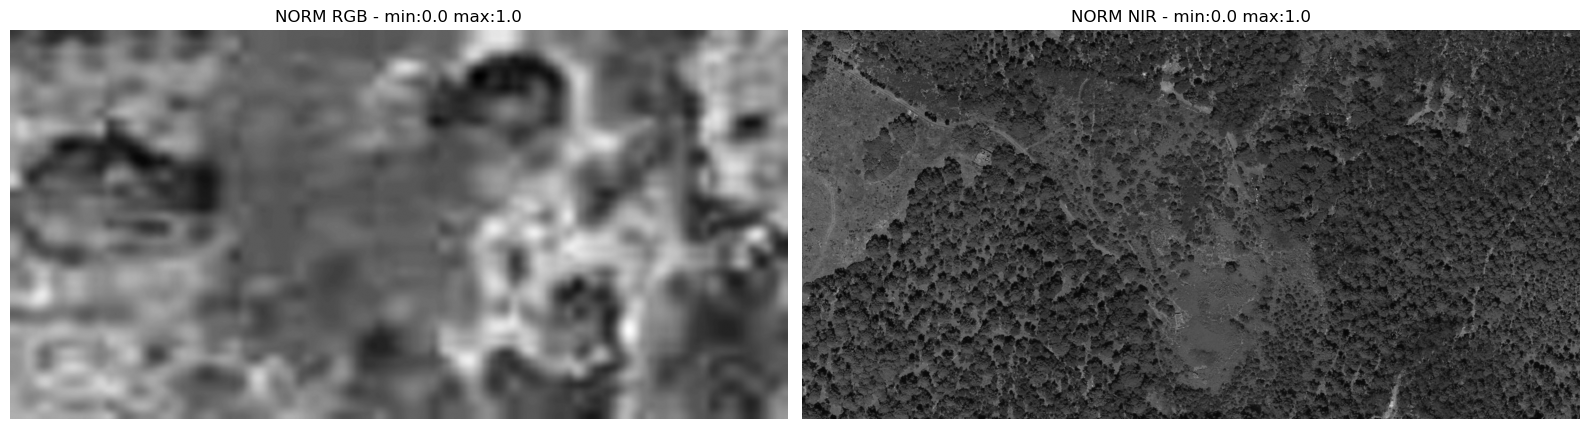

In [7]:
## -- Listas para guardar las imagenes normalizadas -- ##

normRGB_list = []     # Lista para imágenes RGB normalizadas
normNIR_list = []     # Lista para imágener NIR normalizadas 


for n in range(len(img_RGB)):

    ## --- Normalización --- ##
    
    norm_RGB = normalize_image(zoomx2_imgGRAY_list[n])    # Normalizamos la imagen RGB
    norm_NIR = normalize_image(img_IR[n])    # Normalizamos la imagen NIR

    ## --- Guardamos las imagenes normalizadas --- ##
    
    normRGB_list.append(norm_RGB)   # Imagen RGB normalizada
    normNIR_list.append(norm_NIR)   # Imagen NIR normalizada

    ## --- VISUALIZACIÓN --- ##
    plt.figure(figsize=(16,14))

    plt.subplot(1,2,1)
    plt.title(f"NORM RGB - min:{normRGB_list[n].min()} max:{normRGB_list[n].max()}")
    plt.imshow(normRGB_list[n],cmap='gray')
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title(f"NORM NIR - min:{normNIR_list[n].min()} max:{normNIR_list[n].max()}")
    plt.imshow(normNIR_list[n],cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

### STEP II - Cálculo de gradientes

In [8]:
def spatial_derivative(img,dx,dy,ksize=3):
    
    kx, ky = cv2.getDerivKernels(dx,dy,ksize,normalize=True,ktype=cv2.CV_32F)

    derivative = cv2.sepFilter2D(img.astype(np.float32),cv2.CV_32F,kx,ky,borderType=cv2.BORDER_REFLECT101)

    return derivative

In [9]:
## === FUNCIÓN PARA CALCULAR EL GRADIENTE === ##
def compute_gradients(img):

    ## --- Gradiente X --- ##
    fx = spatial_derivative(img,dx=1,dy=0,ksize=3)

    ## --- Gradiente Y --- ##
    fy = spatial_derivative(img,dx=0,dy=1,ksize=3)

    return fx, fy

In [10]:
## --- Listas para guardar el gradiente del RGB --- ##

rgb_GX_list = []    # Lista para gradientes RGB X
rgb_GY_list = []    # Lista para gradientes RGB Y

for n in range(len(img_RGB)):
   
    rgb_gx, rgb_gy = compute_gradients(zoomx2_imgGRAY_list[n])  # Obtención del Gradiente de la imagen RGB

    ## --- Guardamos las gradientes --- ##
    
    rgb_GX_list.append(rgb_gx)   # Gradiente GX
    rgb_GY_list.append(rgb_gy)   # Gradiente GY

### STEP III - Cálculo de la transformación afín, warp y overlap

#### Matriz Afín - v2

In [11]:
## === FUNCIÓN PARA CÁLCULAR EL MODELO AFÍN [u(x,y,p) y v(x,y,p)] === ##
def affine_matrix(image_shape,identity_params):

    ## -- Parámetros referentes a la forma de la imagen -- ##

    H, W = image_shape                           # Alto y ancho de la imagen

    ## -- Matrices de coordenadas bidimensionales -- ##

    y, x = np.indices((H, W), dtype=np.float32)  # Matrices de coordenadas verticales (y) y horizontales (x)

    ## -- Parámetros para la M. Afín -- ##
    
    p1, p2, p3, p4, p5, p6 = identity_params     # Afinidad dada por: escala X, escala Y, shear, rotación y traslación

    ## -- Generar el Modelo Afín [Basado en el paper NTG] -- 

    u = (p1*x + p2*y + p3).astype(np.float32)     # Mapea la coordenada horizontal x
    v = (p4*x + p5*y + p6).astype(np.float32)     # Mapea la coordenada horizontal y
 
    return u, v

#### Warp para NIR - v2

In [12]:
## === FUNCIÓN PARA REALIZAR EL WARP PARA LA IMAGEN EN NIR [basado en el paper] === ###
def warp_image_ntg(img_NIR,identity_params):

    ## --- Cálcular las coordenadas afines --- ##
    u, v = affine_matrix(img_NIR.shape[:2],identity_params)

    ## --- Convertir a float32 para manejar los datos --- ##
    u = u.astype(np.float32)
    v = v.astype(np.float32)

    ## --- Ejecutamos el WarpAffine con REMAP [basado en el paper] con los parámetros dados --- ##
    warped = cv2.remap(
        img_NIR,
        u,
        v,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    return warped

#### Overlaping - v2

In [13]:
## === FUNCIÓN PARA GENERAR EL TRASLAPE EN NIR [puntos con coordenadas validas en NIR] === ##
def warp_mask(img_NIR,identity_params):
    
    ## --- Obtenemos las dimensiones de la imagen --- ##
    H, W = img_NIR.shape

    ## --- Obtenemos las coordenadas afines para el overlaping --- ##
    u, v = affine_matrix(img_NIR.shape,identity_params)

    ## --- Obtenemos la región de overlap --- ##
    warped_mask = (
        (u >= 0) &
        (u < W - 1) &
        (v >= 0) &
        (v < H - 1)
    )

    return warped_mask

### STEP IV - Normalized Total Gradient [NTG] - v2

In [14]:
## === FUNCIÓN PARA CALCULAR EL NUCLEO DEL MÉTODO NTG === ##
def compute_ntg(img_reference,reference_gx,reference_gy,img_floating,identity_params):

    ## --- Warp de la imagen NIR para ajustarla a la RGB [paper] --- ##
    warped = warp_image_ntg(img_floating,
                            identity_params
                           )

    ## --- Máscara de traslape válido --- ##
    mask = warp_mask(img_floating,
                     identity_params
                    )

    overlap_pixels = np.sum(mask)
    overlap_ratio = (overlap_pixels/mask.size)

    ## --- Evitar soluciones invalidas (No se ajustan) --- ##
    if overlap_ratio < 0.80:
        return 1.0

    ## --- Gradientes de la imagen warped NIR --- ##
    warped_gx, warped_gy = compute_gradients(warped)

    ## --- Diferencia entre los gradientes del RGB y NIR warped --- ##
    diff_gx = warped_gx - reference_gx     # Gradiente en X
    diff_gy = warped_gy - reference_gy     # Gradiente en Y

    ## --- Cálculo del Numerador NTG --- ##
    numerator = (np.sum(np.abs(diff_gx[mask])) + np.sum(np.abs(diff_gy[mask])))

    ## --- Cálculo del Denominador NTG --- ##
    denominator = (np.sum(np.abs(warped_gx[mask])) + np.sum(np.abs(warped_gy[mask])) +
                   np.sum(np.abs(reference_gx[mask])) + np.sum(np.abs(reference_gy[mask])))
    
    if denominator < 1e-8:                # Caso para evitar la división entre 0
        return 1.0

    ## --- Cálculo final del NTG del modelo afín --- ##
    ntg = float(numerator / denominator)

    return ntg

In [15]:
NTG_identity_list = []
NTG_shift_list = []

p_identity = np.array([
    1.0, 0.0, 0.0,
    0.0, 1.0, 0.0
])

p_shift = np.array([
    1.0, 0.0, 30.0,
    0.0, 1.0, 20.0
])

for n in range(len(img_RGB)):

    ntg_id = compute_ntg(zoomx2_imgGRAY_list[n],rgb_GX_list[n],rgb_GY_list[n],img_IR[n],p_identity)
    ntg_sh = compute_ntg(zoomx2_imgGRAY_list[n],rgb_GX_list[n],rgb_GY_list[n],img_IR[n],p_shift)

    print(f"NTG identity {n}:", ntg_id)
    print(f"NTG shifted  {n}:", ntg_sh)

NTG identity 0: 0.9503002762794495
NTG shifted  0: 0.949985682964325


## STEP V - Pirámide NTG

In [16]:
### === FUNCIÓN PARA CONSTRUIR LA PIRÁMIDE NTG MULTIRESOLUCIÓN === ##
def build_pyramid(img_RGB,levels,scale):

    pyramid = [img_RGB]            # Lista que almacena las diferentes resoluciones de la imagen de referencia
    current_lv = img_RGB           # Imagen[resolución] actual de trabajo

    for _ in range(levels - 1):

        ## --- Calcular nuevas dimensiones --- ##
        new_width = current_lv.shape[1] // scale     # Dimensiones para el ancho de la imagen
        new_height = current_lv.shape[0] // scale    # Dimensiones para el largo de la imagen

        ## --- Redimensionamos la imagen  --- ##
        current_lv = cv2.resize(
            current_lv,
            (new_width, new_height),
            interpolation=cv2.INTER_AREA
        )

        pyramid.append(current_lv)

    return pyramid

In [17]:
## === FUNCIÓN PARA AJUSTAR EL ORDEN DE LA PIRÁMIDE SMALL2LARGE === ##
def build_NTG_pyramid(img_RGB,levels,scale):

    ## --- Construimos la pirámide base para el modelo --- ##
    pyramid_NTG = build_pyramid(
        img_RGB,
        levels,
        scale
    )

    ## --- Invertimos el orden de la pirámide del MÁS PEQUEÑO al MÁS GRANDE --- ##
    pyramid_NTG.reverse()

    return pyramid_NTG

In [18]:
rgb_pyramid = build_NTG_pyramid(
    zoomx2_imgGRAY_list[0],
    levels=4,
    scale=2
)

nir_pyramid = build_NTG_pyramid(
    img_IR[0],
    levels=4,
    scale=2
)

for k in range(4):

    print(
        f"Level {k}:",
        "RGB =", rgb_pyramid[k].shape,
        "NIR =", nir_pyramid[k].shape
    )

Level 0: RGB = (122, 245) NIR = (122, 245)
Level 1: RGB = (245, 491) NIR = (245, 491)
Level 2: RGB = (491, 982) NIR = (491, 982)
Level 3: RGB = (982, 1964) NIR = (982, 1964)


In [19]:
rgb_gradients = []

for img in rgb_pyramid:

    gx, gy = compute_gradients(img)

    rgb_gradients.append(
        (gx, gy)
    )
    #print(f"GX:",gx)
    #print(f"GY:",gy)

## STEP VI - Differential Evolution

#### Límites afines base v2

In [20]:
def dynamic_params_bounds(img_reference,translation_ratio=0.30,
                          scale_min=0.70,scale_max=2.0,
                          shear_max=0.03):

    ## --- Dimensiones de la imagen para encontrar los límites --- ##
    H, W = img_reference.shape[:2]

    max_tx = translation_ratio * W     # Traslación máxima en el ancho de la imagen
    max_ty = translation_ratio * H     # Traslación máxima en el alto de la imagen

    bounds = [

        # P1 - Escala principal X
        (scale_min, scale_max),  

        # P2 - Shear / Rotation
        (-shear_max, shear_max),   
        
        # P3 - Tx
        (-max_tx, max_tx),                      

        # P4 - Shear / Rotation
        (-shear_max, shear_max),  

        # P5 - Escala principal Y
        (scale_min, scale_max),  

        # P6 - Ty
        (-max_ty, max_ty)                       
    ]

    return bounds

#### Función Differential Evolution por capa

In [21]:
def opt_NTG_diffEVO(img_reference,img_floating,bounds,population=30,generations=200,seed=42):

    ref_gx, ref_gy = compute_gradients(img_reference)

    def objetive(identity_params):

        return compute_ntg(img_reference,ref_gx,ref_gy,img_floating,identity_params)

    result = differential_evolution(objetive,
                                   bounds=bounds,
                                   popsize=population,
                                   maxiter=generations,
                                   polish=False,
                                   seed=seed,
                                   workers=1,
                                   updating="immediate",
                                   disp=True
                                   )
    return result

#### LOCAL BOUNDS - [Coarse-To-Fine Refinement]

In [22]:
def local_bounds(identity_params,delta_linear=0.01,delta_translation=2.0):

    p = np.asarray(identity_params,dtype=np.float64)

    bounds = [

        # BOUNDS - p1
        (p[0] - delta_linear, p[0] + delta_linear),

        # BOUNDS - p2
        (p[1] - delta_linear, p[1] + delta_linear),

        # BOUNDS - P3 [Translation X]
        (p[2] - delta_translation, p[2] + delta_translation),

        # BOUNDS - p4 
        (p[3] - delta_linear, p[3] + delta_linear),

        # BOUNDS - p5
        (p[4] - delta_linear, p[4] + delta_linear),

        # BOUNDS - P6 [Translation Y]
        (p[5] - delta_translation, p[5] + delta_translation)        
    ]

    return bounds

#### DYNAMIC IMPLEMENTATIONS - Scan, range & opt. level

In [23]:
def global_scale_scan(img_reference,img_floating,
                      scale_bounds=(0.005, 1.05),
                      num_samples=200):

    scales = np.linspace(
        scale_bounds[0],
        scale_bounds[1],
        num_samples
    )

    ref_gx, ref_gy = compute_gradients(img_reference)

    H, W = img_reference.shape[:2]

    cx = (W - 1) / 2.0
    cy = (H - 1) / 2.0

    ntg_values = []

    for s in scales:

        p = np.array([s, 0.0, cx*(1.0 - s),
                      0.0, s, cy*(1.0 - s)],
                      dtype=np.float64)

        value = compute_ntg(img_reference, ref_gx, ref_gy, img_floating, p)

        ntg_values.append(value)

    ntg_values = np.asarray(ntg_values)

    idx = np.argmin(ntg_values)

    return (scales[idx], ntg_values[idx], scales, ntg_values)

In [24]:
def find_reliable_global_level(reference_pyramid,floating_pyramid,
                               scale_bounds=(0.005, 1.05),
                               scale_samples=300,
                               consistency_tol=0.02):

    results = []

    for level in range(len(reference_pyramid) - 1):

        s_scan, ntg_scan, _, _ = global_scale_scan(reference_pyramid[level],floating_pyramid[level],
                                                   scale_bounds=scale_bounds,num_samples=scale_samples)

        results.append({
            "level": level,
            "scale": s_scan,
            "ntg": ntg_scan
        })

        print(f"Level {level}: ",
              f"Scale = {s_scan:.6f}",
              f"NTG = {ntg_scan:.6f}")

        ## ---- Buscar entre dos niveles consecutivos consistentes ---- ##

        for i in range(len(results) - 1):

            s_a = results[i]["scale"]
            s_b = results[i + 1]["scale"]

            relative_difference = (abs(s_a - s_b)/max(abs(s_b), 1e-8))

            if relative_difference <= consistency_tol:

                # --- Elegimos el nivel más bajo de los dos --- #
                return (results[i]["level"],results)

    # --- Si ninguno coincide, usar el nivel más alto evaluado --- #
    return (results[-1]["level"],results)
            

In [25]:
def refine_centered_scale_scalar(img_reference,img_floating,s_initial, 
                                 delta_s=0.01,global_bounds=(0.005, 1.05)):

    ref_gx, ref_gy = compute_gradients(img_reference)

    H, W = img_reference.shape[:2]

    cx = (W - 1) / 2.0
    cy = (H - 1) / 2.0

    def objective(s):

        p = np.array([s, 0.0, cx*(1.0 - s),
                      0.0, s, cy*(1.0 - s)],
                      dtype=np.float64)

        return compute_ntg(img_reference,ref_gx,ref_gy,img_floating,p)

    lower = max(global_bounds[0],s_initial - delta_s)
    upper = min(global_bounds[1],s_initial + delta_s)

    result = minimize_scalar(objective,bounds=(lower,upper),
                             method="bounded",options={"xatol": 1e-6})

    s_refined = float(result.x)

    p_refined = np.array([s_refined, 0.0, cx*(1.0 - s_refined),
                          0.0, s_refined, cy*(1.0 - s_refined)],
                          dtype=np.float64)

    return p_refined, result

In [26]:
def opt_NTG_centered_scale_DE(img_reference,img_floating,
                              scale_bounds=(0.005, 1.05),
                              population=30,generations=200,
                              seed=42):

    ref_gx, ref_gy = compute_gradients(img_reference)

    H, W = img_reference.shape[:2]

    cx = (W - 1) / 2.0
    cy = (H - 1) / 2.0

    def objetive(scale_array):

        s = float(scale_array[0])
        p = np.array([s, 0.0, cx*(1.0 - s),
                      0.0, s, cy*(1.0 - s)],
                      dtype=np.float64)

        return compute_ntg(img_reference,ref_gx,ref_gy,img_floating,p)

    result = differential_evolution(objetive,bounds=[scale_bounds],
                                    popsize=population,maxiter=generations,
                                    polish=False,seed=seed,workers=1,
                                    updating="immediate")

    s = float(result.x[0])

    p_estimated = np.array([s, 0.0, cx*(1.0 - s),
                            0.0, s, cy*(1.0 - s)],
                            dtype=np.float64)

    return p_estimated, result

#### EVALUATE CURRENT NTG 

In [27]:
def evaluate_current_ntg(img_reference,img_floating,identity_params):

    ref_gx, ref_gy = compute_gradients(img_reference)

    value = compute_ntg(img_reference,ref_gx,ref_gy,img_floating,identity_params)

    return value

In [28]:
bottom_rgb = rgb_pyramid[0]
bottom_nir = nir_pyramid[0]

bounds = dynamic_params_bounds(bottom_rgb,translation_ratio=0.30,
                          scale_min=0.70,scale_max=2.0,
                          shear_max=0.03)

result_bottom = opt_NTG_diffEVO(
    bottom_rgb,
    bottom_nir,
    bounds,
    population=30,
    generations=200,
    seed=42
)

print("\nBottom level")
print("NTG:", result_bottom.fun)
print("p:", result_bottom.x)

differential_evolution step 1: f(x)= 0.7556142210960388
differential_evolution step 2: f(x)= 0.7556142210960388
differential_evolution step 3: f(x)= 0.7556142210960388
differential_evolution step 4: f(x)= 0.7556142210960388
differential_evolution step 5: f(x)= 0.7536253929138184
differential_evolution step 6: f(x)= 0.7536253929138184
differential_evolution step 7: f(x)= 0.7536253929138184
differential_evolution step 8: f(x)= 0.7500706911087036
differential_evolution step 9: f(x)= 0.7500706911087036
differential_evolution step 10: f(x)= 0.7500706911087036
differential_evolution step 11: f(x)= 0.7487037181854248
differential_evolution step 12: f(x)= 0.7487037181854248
differential_evolution step 13: f(x)= 0.7487037181854248

Bottom level
NTG: 0.7487037181854248
p: [ 7.43715080e-01  3.62756714e-03  6.65997329e+01 -6.61369176e-03
  7.18608138e-01  1.02708574e+01]


## STEP VII - Parameter Transfer

In [29]:
def transfer_affine_parameters(identity_params,scale_factor=2):

    p_new = np.array(identity_params,
                    dtype=np.float32
                    ).copy()

    # Traslación
    p_new[2] *= scale_factor
    p_new[5] *= scale_factor

    return p_new

## STEP VIII - NTG v1 + Pyramid v2 + Propagation

In [30]:
### === COARSE-TO-FINE ITERATIVE REFINEMENT === ##
def pip_NTG_pyramid_coarse2fine(img_reference,img_floating,
                                levels=4,scale_factor=2,
                                
                                # -- Global scale scan -- #
                                scale_bounds=(0.005, 1.05),
                                scale_samples=300,
                                delta_scale=0.01,
                                consistency_tol=0.02,

                                # -- Local DE -- #
                                local_population=10,
                                local_generations=30,

                                # -- Local search region -- ##
                                delta_linear=0.01,
                                delta_translation=2.0,
                                
                                seed=42
                               ):

    ## ==== CONSTRUCCIÓN DE LAS PIRÁMIDES ==== ##

    # Pirámide de referencia (RGB)
    reference_pyramid = build_NTG_pyramid(img_reference,levels=levels,scale=scale_factor)

    # Pirámide de trabajo (NIR)
    floating_pyramid = build_NTG_pyramid(img_floating,levels=levels,scale=scale_factor)

    # Historial
    history = []

    ## ==== SELECCIÓN DINÁMICA DEL NIVEL GLOBAL ==== ##

    print("\n================================")
    print("GLOBAL LEVEL SELECTION")
    print("================================")

    global_level, level_scan_results = find_reliable_global_level(
        reference_pyramid,floating_pyramid,
        scale_bounds=scale_bounds,
        scale_samples=scale_samples,
        consistency_tol=consistency_tol
    )

    print(f"Selected Global Level: {global_level}")
    

    ## ==== OPTIMIZACIÓN GLOBAL [nivel 0] ==== ##

    print("\n================================")
    print("GLOBAL OPTIMIZATION")
    print("================================")
    
    ref_level = reference_pyramid[global_level]       # Nivel de la pirámide RGB
    flo_level = floating_pyramid[global_level]        # Nivel de la pirámide NIR

    ## ---- Barrido global de escala ---- ##
    
    s_scan, ntg_scan, scales, ntg_values = global_scale_scan(
        ref_level,
        flo_level,

        scale_bounds=scale_bounds,
        num_samples=scale_samples
    )

    print(f"\nScale from scan: {s_scan:.8f}")
    print(f"NTG scan: {ntg_scan:.8f}")

    ## ---- Refinamiento escalar local ---- ##

    identity_params, result_scalar = refine_centered_scale_scalar(
        ref_level,
        flo_level,

        s_initial=s_scan,

        delta_s=delta_scale,

        global_bounds=scale_bounds
    )

    ## ---- NTG después del refinamiento escalar ---- ##
    ntg_level = evaluate_current_ntg(ref_level,flo_level,identity_params)

    print(f"\nLevel {global_level} parameters:")
    print(identity_params)
    print(f"Refined scale: {identity_params[0]:.8f}")
    print(f"NTG Level 0 = {ntg_level:.8f}")
    
    history.append({
        "level": global_level,
        "global_level": global_level,
        "shape": ref_level.shape,
        "transferred_parameters": None,
        "parameters": identity_params.copy(),
        "scale_scan": s_scan,
        "scale_refined": identity_params[0],
        "NTG_scan": ntg_scan,
        "NTG_after": ntg_level,
        "improvement": ntg_scan - ntg_level,
        "level_scan_results": level_scan_results
        
    })

    ## ==== COARSE-TO-FINE ==== ##
    for level in range(global_level + 1,levels):
        
        print("\n================================")
        print(f"LEVEL {level} - LOCAL REFINEMENT")
        print("================================")

        ## --- Imágenes del nivel actual --- ##
        ref_level = reference_pyramid[level]
        flo_level = floating_pyramid[level]

        print("Resolution:",ref_level.shape)

        ## --- Transferir solución del nivel anterior --- ##
        p_transferred = transfer_affine_parameters(identity_params,scale_factor=scale_factor)
        
        print("Transferred parameters:")
        print(p_transferred)

        ## === NTG ANTES del refinamiento === ##
        ntg_before = evaluate_current_ntg(ref_level,flo_level,p_transferred)

        print(f"NTG before refinement: {ntg_before:.6f}")

        ## --- Construir región local --- ##
        bounds_level = local_bounds(p_transferred,
                                    delta_linear=delta_linear,
                                    delta_translation=delta_translation)

        ## --- Resultados LOCALES --- ##
        result_local = opt_NTG_diffEVO(ref_level,flo_level,bounds_level,
                                      population=local_population,
                                      generations=local_generations,
                                      seed=seed+level)

        ## --- Resultado LOCAL propuesto --- ##
        params_candidate = result_local.x.copy()

        ## === NTG DESPUÉS del refinamiento === ##
        ntg_candidate = evaluate_current_ntg(ref_level,flo_level,params_candidate)

        if ntg_candidate < ntg_before:

            identity_params = params_candidate
            ntg_after = ntg_candidate
            accepted = True

        else:
            
            identity_params = params_candidate.copy()
            ntg_after = ntg_before
            accepted = False
        
        improvement = (ntg_before - ntg_after)

        print("Local refinement accepted:", accepted)
        print("Refined parameters:")
        print(identity_params)
        print(f"NTG after refinament: {ntg_after:.6f}")
        print(f"Improvement: {improvement:.6f}")

        ## -- Guardar historial -- ##
        
        history.append({
            "level": level,
            "shape": ref_level.shape,
            "transferred_parameters": p_transferred.copy(),
            "candidate_parameters": params_candidate.copy(),
            "parameters": identity_params.copy(),
            "NTG_before": ntg_before,
            "NTG_candidate": ntg_candidate,
            "NTG_after": ntg_after,
            "improvement": improvement,
            "accepted": accepted
        })

        print("Parámetros Transferidos:")
        print(identity_params)

    return identity_params, history

In [31]:
trasl_x = 0
trasl_y = 0

p_shift = np.array([
    1.0, 0.0, float(trasl_x),
    0.0, 1.0, float(trasl_y)
])

nir_shifted = warp_image_ntg(
    img_IR[0],
    p_shift
)


In [32]:
p_estimated_c2f, history_c2f = pip_NTG_pyramid_coarse2fine(
    zoomx2_imgGRAY_list[0],
    img_IR[0],

    levels=4,
    scale_factor=2,

    scale_bounds=(0.005, 1.05),
    scale_samples=300,
    delta_scale=0.01,
    consistency_tol=0.02,

    local_population=10,
    local_generations=30,

    delta_linear=0.01,
    delta_translation=2.0,

    seed=42
)


GLOBAL LEVEL SELECTION
Level 0:  Scale = 0.270619 NTG = 0.737082
Level 1:  Scale = 0.050435 NTG = 0.680870
Level 2:  Scale = 0.050435 NTG = 0.470384
Selected Global Level: 1

GLOBAL OPTIMIZATION

Scale from scan: 0.05043478
NTG scan: 0.68086976

Level 1 parameters:
[4.99669120e-02 0.00000000e+00 2.32758107e+02 0.00000000e+00
 4.99669120e-02 1.15904037e+02]
Refined scale: 0.04996691
NTG Level 0 = 0.67951101

LEVEL 2 - LOCAL REFINEMENT
Resolution: (491, 982)
Transferred parameters:
[4.9966913e-02 0.0000000e+00 4.6551620e+02 0.0000000e+00 4.9966913e-02
 2.3180807e+02]
NTG before refinement: 0.624607
differential_evolution step 1: f(x)= 0.7038277983665466
differential_evolution step 2: f(x)= 0.6122235059738159
differential_evolution step 3: f(x)= 0.6063022613525391
differential_evolution step 4: f(x)= 0.6063022613525391
differential_evolution step 5: f(x)= 0.6063022613525391
differential_evolution step 6: f(x)= 0.5967186689376831
differential_evolution step 7: f(x)= 0.5700976848602295
dif

In [33]:
print("\n")
print("=" * 60)
print("FINAL PARAMETERS")
print("=" * 60)

print(
    p_estimated_c2f
)



FINAL PARAMETERS
[5.02252856e-02 7.59521311e-04 9.31850124e+02 2.10636812e-04
 5.01237963e-02 4.65185006e+02]


In [34]:
def pip_NTG_pyramid_wDE(img_reference,img_floating,
                        levels=4,scale_factor=2,

                        # --- Global scale search --- #
                        scale_bounds=(0.005, 1.05),
                        scale_samples=300,
                        delta_scale=0.01,
                        consistency_tol=0.02,
                        
                        seed=42
                       ):

    ## --- Construimos las pirámides --- ##

    # Pirámide de referencia (RGB)
    reference_pyramid = build_NTG_pyramid(img_reference,levels=levels,scale=scale_factor)

    # Pirámide de trabajo (NIR)
    floating_pyramid = build_NTG_pyramid(img_floating,levels=levels,scale=scale_factor)

    history = []

    ## ===== SELECCIONAR NIVEL GLOBAL FIABLE ===== ##
    print("\n================================")
    print("GLOBAL LEVEL SELECTION")
    print("================================")

    global_level, level_scan_results = find_reliable_global_level(reference_pyramid,floating_pyramid,
                                                                  scale_bounds=scale_bounds,
                                                                  scale_samples=scale_samples,
                                                                  consistency_tol=consistency_tol)

    print(f"Selected global level: {global_level}")

    ## ===== SCAN GLOBAL EN EL NIVEL SELECCIONADO ===== ##

    ref_level = reference_pyramid[global_level]
    flo_level = floating_pyramid[global_level]

    print("\n================================")
    print(f"GLOBAL SCALE SEARCH - LEVEL {global_level}")
    print("================================")

    s_scan, ntg_scan, scales, ntg_values = global_scale_scan(ref_level,flo_level,
                                                             scale_bounds=scale_bounds,
                                                             num_samples=scale_samples)

    print(f"Scale from scan: {s_scan:.8f}")
    print(f"NTG scan: {ntg_scan:.8f}")


    ## --- Optimización Global en el nivel bajo --- ##

    print("\n================================")
    print("REFINAMIENTO ESCALAR")
    print("================================")

    identity_params, result_scalar = refine_centered_scale_scalar(ref_level,flo_level,
                                                                  s_initial=s_scan,
                                                                  delta_s=delta_scale,
                                                                  global_bounds=scale_bounds)

    ntg_global = evaluate_current_ntg(ref_level,flo_level,identity_params)

    print(f"Global Refined Parameters: {identity_params}")
    print(f"Refined Scale: {identity_params[0]:.8f}")
    print(f"NTG global level: {ntg_global:.8f}")
    
    history.append({
        "level": global_level,
        "global_level": global_level,
        "shape": ref_level.shape,
        "parameters": identity_params.copy(),
        "scale_scan": s_scan,
        "scale_refined": identity_params[0],
        "NTG_scan": ntg_scan,
        "NTG_after": ntg_global,
        "level_scan_results": level_scan_results
    })

    ## --- Transferencia hacia arriba --- ##

    for level in range(global_level+1,levels):

        print("\n================================")
        print(f"LEVEL {level} - Propagation only")
        print("================================")

        identity_params = transfer_affine_parameters(identity_params,scale_factor=scale_factor)

        history.append({
            "level": level,
            "parameters": identity_params.copy(),
            "refined": False
        })

        print("Parámetros Transferidos:")
        print(identity_params)

    return identity_params, history

In [35]:
p_estimated, history = pip_NTG_pyramid_wDE(
    zoomx2_imgGRAY_list[0],
    img_IR[0],
    levels=4,
    scale_factor=2,
    scale_bounds=(0.005, 1.05),
    scale_samples=300,
    delta_scale=0.01,
    consistency_tol=0.02,
    seed=42
)

print("\nFinal parameters:")
print(p_estimated)


GLOBAL LEVEL SELECTION
Level 0:  Scale = 0.270619 NTG = 0.737082
Level 1:  Scale = 0.050435 NTG = 0.680870
Level 2:  Scale = 0.050435 NTG = 0.470384
Selected global level: 1

GLOBAL SCALE SEARCH - LEVEL 1
Scale from scan: 0.05043478
NTG scan: 0.68086976

REFINAMIENTO ESCALAR
Global Refined Parameters: [4.99669120e-02 0.00000000e+00 2.32758107e+02 0.00000000e+00
 4.99669120e-02 1.15904037e+02]
Refined Scale: 0.04996691
NTG global level: 0.67951101

LEVEL 2 - Propagation only
Parámetros Transferidos:
[4.9966913e-02 0.0000000e+00 4.6551620e+02 0.0000000e+00 4.9966913e-02
 2.3180807e+02]

LEVEL 3 - Propagation only
Parámetros Transferidos:
[4.9966913e-02 0.0000000e+00 9.3103241e+02 0.0000000e+00 4.9966913e-02
 4.6361615e+02]

Final parameters:
[4.9966913e-02 0.0000000e+00 9.3103241e+02 0.0000000e+00 4.9966913e-02
 4.6361615e+02]


In [36]:
estimated_scale = (
    p_estimated_c2f[0]
)

expected_scale = (
    1.0 / zoom_factor_v0
)

print(
    "Expected scale:",
    expected_scale
)

print(
    "Estimated scale:",
    estimated_scale
)

print(
    "Scale error:",
    abs(
        estimated_scale
        -
        expected_scale
    )
)

Expected scale: 0.05
Estimated scale: 0.05022528558749081
Scale error: 0.00022528558749080468


In [37]:
for item in history_c2f:

    print("\n")
    print(
        f"LEVEL {item['level']}"
    )

    print(
        "Resolution:",
        item["shape"]
    )

    if (
        item[
            "transferred_parameters"
        ]
        is not None
    ):

        print(
            "Transferred:"
        )

        print(
            item[
                "transferred_parameters"
            ]
        )

    print(
        "Refined:"
    )

    print(
        item["parameters"]
    )

    print(
        "NTG after:",
        item["NTG_after"]
    )

    if (
        item["improvement"]
        is not None
    ):

        print(
            "Improvement:",
            item["improvement"]
        )



LEVEL 1
Resolution: (245, 491)
Refined:
[4.99669120e-02 0.00000000e+00 2.32758107e+02 0.00000000e+00
 4.99669120e-02 1.15904037e+02]
NTG after: 0.6795110106468201
Improvement: 0.0013587474822998047


LEVEL 2
Resolution: (491, 982)
Transferred:
[4.9966913e-02 0.0000000e+00 4.6551620e+02 0.0000000e+00 4.9966913e-02
 2.3180807e+02]
Refined:
[ 4.99936234e-02 -4.07922044e-04  4.66021229e+02  7.23857934e-05
  4.93718469e-02  2.32762393e+02]
NTG after: 0.4521542489528656
Improvement: 0.1724526584148407


LEVEL 3
Resolution: (982, 1964)
Transferred:
[ 4.9993623e-02 -4.0792205e-04  9.3204248e+02  7.2385796e-05
  4.9371846e-02  4.6552478e+02]
Refined:
[5.02252856e-02 7.59521311e-04 9.31850124e+02 2.10636812e-04
 5.01237963e-02 4.65185006e+02]
NTG after: 0.3959400951862335
Improvement: 0.05192992091178894


In [38]:
# ============================================================
# VISUAL TEST - NTG ALIGNMENT
# Pyramid + Differential Evolution
# ============================================================

# Imagen RGB de referencia
rgb_ref = zoomx2_imgGRAY_list[0]

# RGB en grayscale
rgb_gray_ref = zoomx2_imgGRAY_list[0]

# NIR con desplazamiento artificial
nir_before = img_IR[0]

# Aplicamos la transformación encontrada por NTG
nir_after = warp_image_ntg(
    nir_before,
    p_estimated_c2f
)

print("Parámetros estimados:")
print(p_estimated_c2f)

Parámetros estimados:
[5.02252856e-02 7.59521311e-04 9.31850124e+02 2.10636812e-04
 5.01237963e-02 4.65185006e+02]


In [39]:
H, W = img_RGBgray[0].shape

cx = (W - 1) / 2.0
cy = (H - 1) / 2.0

s_gt = 1.0 / zoom_factor_v0

p_gt_zoom = np.array([
    s_gt,
    0.0,
    cx * (1.0 - s_gt),

    0.0,
    s_gt,
    cy * (1.0 - s_gt)
], dtype=np.float64)

print("GT zoom:")
print(p_gt_zoom)

print("\nEstimated:")
print(p_estimated_c2f)

print("\nError:")
print(p_estimated_c2f - p_gt_zoom)

GT zoom:
[5.00000e-02 0.00000e+00 9.32425e+02 0.00000e+00 5.00000e-02 4.65975e+02]

Estimated:
[5.02252856e-02 7.59521311e-04 9.31850124e+02 2.10636812e-04
 5.01237963e-02 4.65185006e+02]

Error:
[ 2.25285587e-04  7.59521311e-04 -5.74876489e-01  2.10636812e-04
  1.23796326e-04 -7.89994071e-01]


In [40]:
tx_error = p_estimated_c2f[2] - p_gt_zoom[2]
ty_error = p_estimated_c2f[5] - p_gt_zoom[5]

translation_error_zoom = np.sqrt(
    tx_error**2 +
    ty_error**2
)

print(
    "Translation error zoom:",
    translation_error_zoom
)

Translation error zoom: 0.9770228298657769


In [41]:
sx_error = p_estimated_c2f[0] - p_gt_zoom[0]
sy_error = p_estimated_c2f[4] - p_gt_zoom[4]

scale_error = np.sqrt(
    sx_error**2 +
    sy_error**2
)

print(
    "Scale error:",
    scale_error
)

Scale error: 0.0002570586046489755


In [42]:
scale_error_percent_x = (
    abs(sx_error) /
    abs(p_gt_zoom[0])
) * 100.0

scale_error_percent_y = (
    abs(sy_error) /
    abs(p_gt_zoom[4])
) * 100.0

print(
    "Scale X error (%):",
    scale_error_percent_x
)

print(
    "Scale Y error (%):",
    scale_error_percent_y
)

Scale X error (%): 0.45057117498160937
Scale Y error (%): 0.24759265169226052


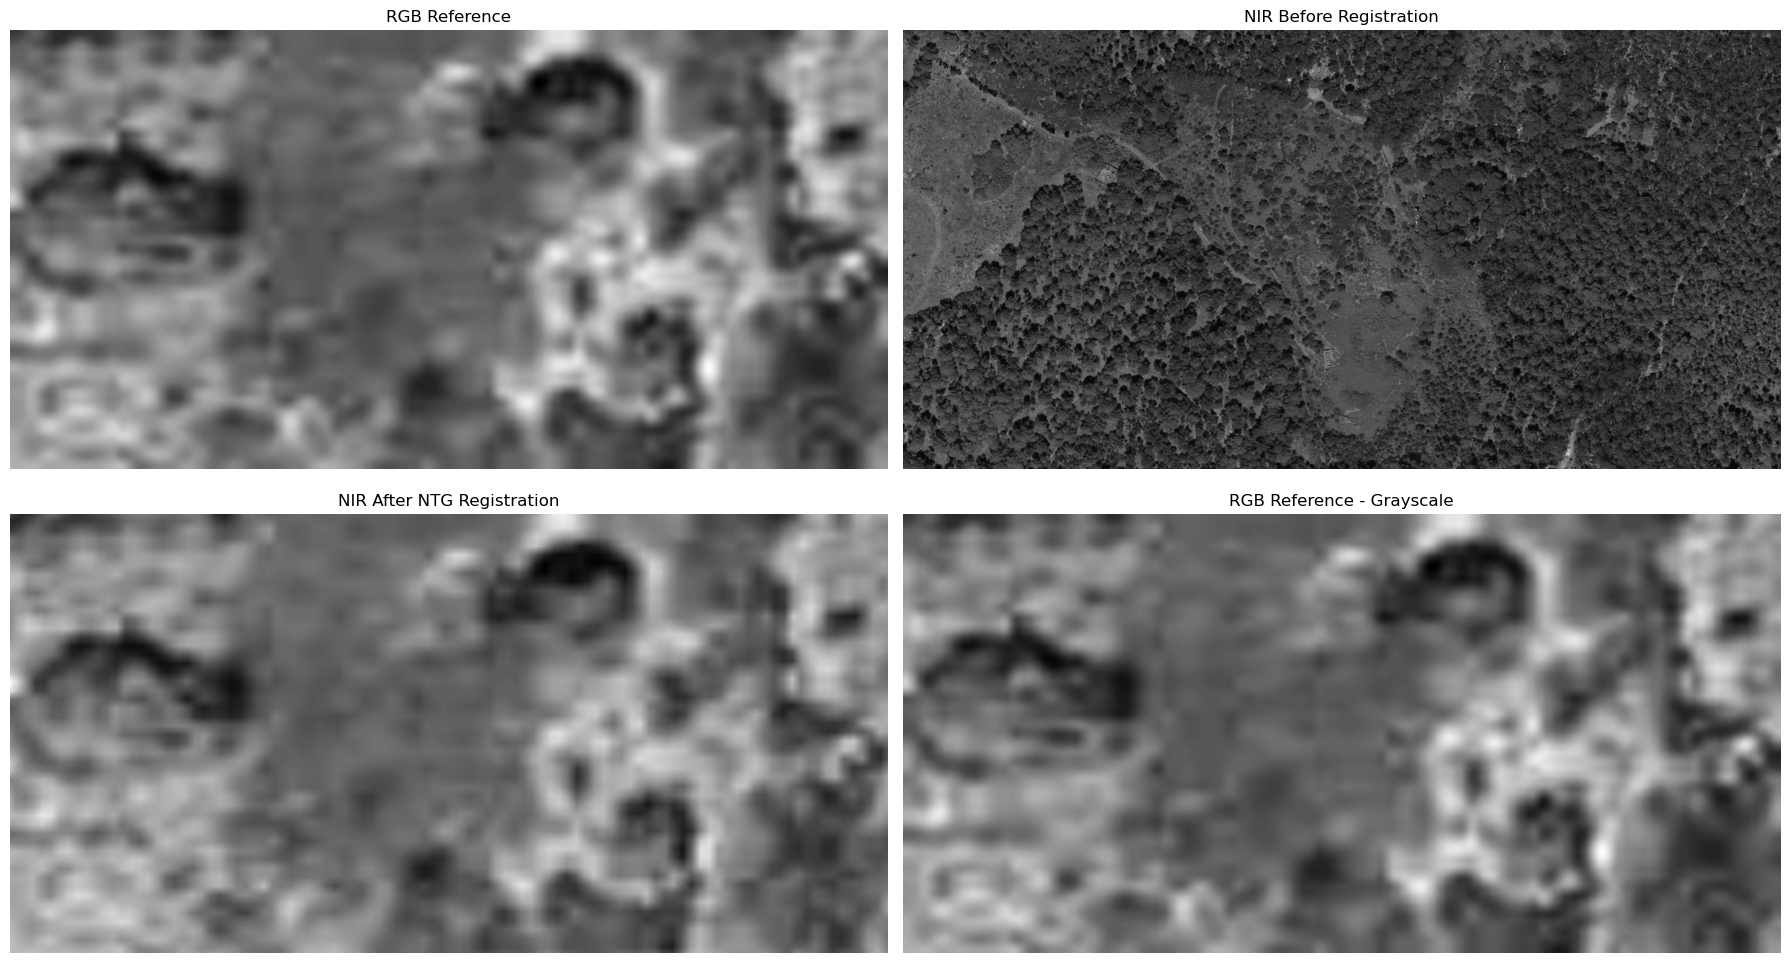

In [43]:
plt.figure(figsize=(18, 10))

# ------------------------------------------------------------
# RGB
# ------------------------------------------------------------

plt.subplot(2, 2, 1)

plt.imshow(rgb_ref,cmap='gray')

plt.title(
    "RGB Reference"
)

plt.axis("off")


# ------------------------------------------------------------
# NIR desplazada
# ------------------------------------------------------------

plt.subplot(2, 2, 2)

plt.imshow(
    nir_before,
    cmap="gray"
)

plt.title(
    "NIR Before Registration"
)

plt.axis("off")


# ------------------------------------------------------------
# NIR registrada
# ------------------------------------------------------------

plt.subplot(2, 2, 3)

plt.imshow(
    nir_after,
    cmap="gray"
)

plt.title(
    "NIR After NTG Registration"
)

plt.axis("off")


# ------------------------------------------------------------
# RGB grayscale
# ------------------------------------------------------------

plt.subplot(2, 2, 4)

plt.imshow(
    rgb_gray_ref,
    cmap="gray"
)

plt.title(
    "RGB Reference - Grayscale"
)

plt.axis("off")


plt.tight_layout()
plt.show()

In [44]:
def normalize_visual(img):

    img = img.astype(np.float32)

    min_val = np.min(img)
    max_val = np.max(img)

    return (
        img - min_val
    ) / (
        max_val - min_val + 1e-8
    )

In [45]:
rgb_vis = normalize_visual(
    rgb_gray_ref
)

nir_before_vis = normalize_visual(
    nir_before
)

nir_after_vis = normalize_visual(
    nir_after
)

In [46]:
# ============================================================
# FALSE-COLOR OVERLAY
#
# RED   = RGB
# GREEN = NIR
#
# Si las estructuras coinciden espacialmente,
# los bordes rojo/verde se superponen.
# ============================================================

overlay_before = np.zeros(
    (
        rgb_vis.shape[0],
        rgb_vis.shape[1],
        3
    ),
    dtype=np.float32
)

overlay_after = np.zeros_like(
    overlay_before
)


# BEFORE
overlay_before[:, :, 0] = rgb_vis
overlay_before[:, :, 1] = nir_before_vis


# AFTER
overlay_after[:, :, 0] = rgb_vis
overlay_after[:, :, 1] = nir_after_vis

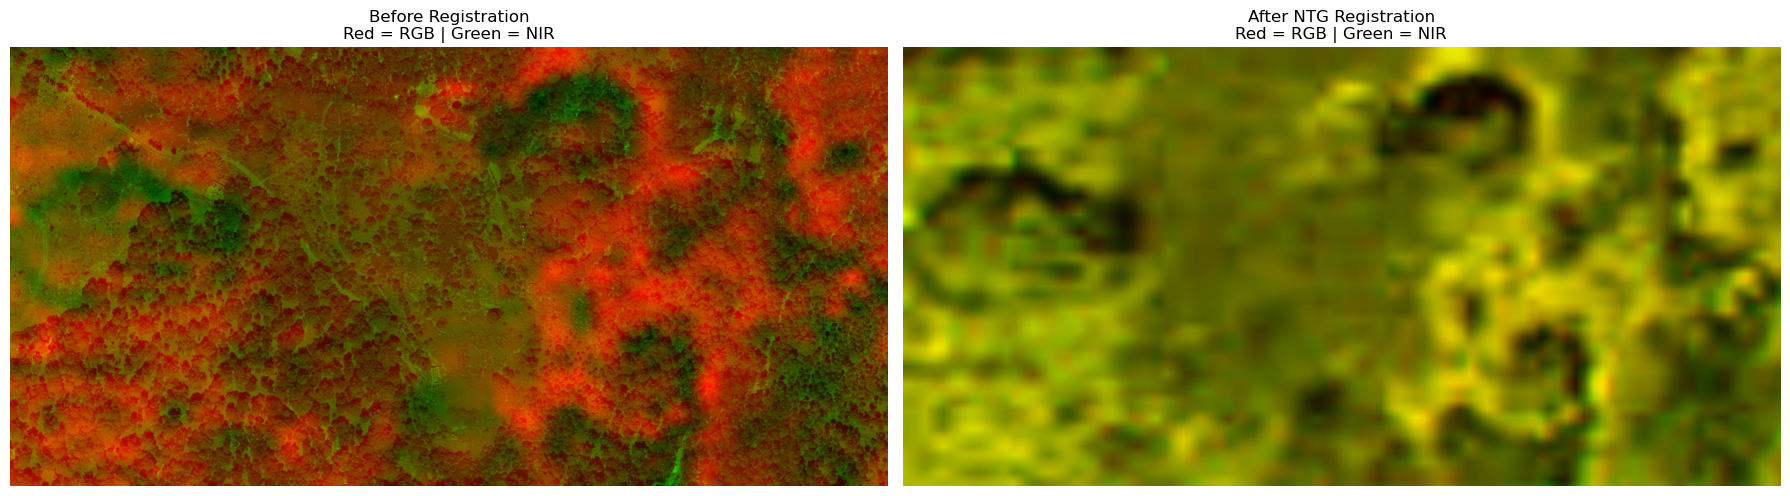

In [47]:
# ============================================================
# FALSE-COLOR OVERLAY
#
# RED   = RGB
# GREEN = NIR
#
# Si las estructuras coinciden espacialmente,
# los bordes rojo/verde se superponen.
# ============================================================

overlay_before = np.zeros(
    (
        rgb_vis.shape[0],
        rgb_vis.shape[1],
        3
    ),
    dtype=np.float32
)

overlay_after = np.zeros_like(
    overlay_before
)


# BEFORE
overlay_before[:, :, 0] = rgb_vis
overlay_before[:, :, 1] = nir_before_vis


# AFTER
overlay_after[:, :, 0] = rgb_vis
overlay_after[:, :, 1] = nir_after_vis

plt.figure(figsize=(18, 8))


plt.subplot(1, 2, 1)

plt.imshow(
    overlay_before
)

plt.title(
    "Before Registration\n"
    "Red = RGB | Green = NIR"
)

plt.axis("off")


plt.subplot(1, 2, 2)

plt.imshow(
    overlay_after
)

plt.title(
    "After NTG Registration\n"
    "Red = RGB | Green = NIR"
)

plt.axis("off")


plt.tight_layout()
plt.show()

In [48]:
for item in history:

    print(
        f"Level {item['level']}: "
        f"{item['parameters']}"
    )

Level 1: [4.99669120e-02 0.00000000e+00 2.32758107e+02 0.00000000e+00
 4.99669120e-02 1.15904037e+02]
Level 2: [4.9966913e-02 0.0000000e+00 4.6551620e+02 0.0000000e+00 4.9966913e-02
 2.3180807e+02]
Level 3: [4.9966913e-02 0.0000000e+00 9.3103241e+02 0.0000000e+00 4.9966913e-02
 4.6361615e+02]


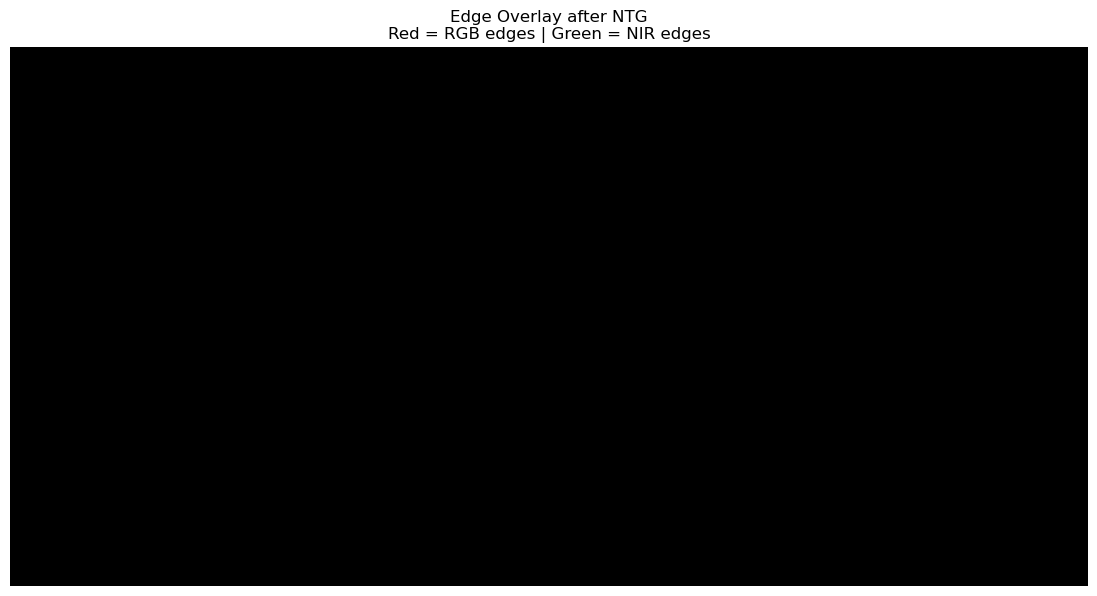

In [49]:
rgb_edges = cv2.Canny(
    (rgb_vis * 255).astype(np.uint8),
    50,
    150
)

nir_edges = cv2.Canny(
    (nir_after_vis * 255).astype(np.uint8),
    50,
    150
)

edge_overlay = np.zeros(
    (
        rgb_edges.shape[0],
        rgb_edges.shape[1],
        3
    ),
    dtype=np.float32
)

edge_overlay[:, :, 0] = rgb_edges / 255.0
edge_overlay[:, :, 1] = nir_edges / 255.0

plt.figure(figsize=(14, 7))

plt.imshow(edge_overlay)

plt.title(
    "Edge Overlay after NTG\n"
    "Red = RGB edges | Green = NIR edges"
)

plt.axis("off")
plt.show()

In [50]:
def checkerboard_images(
    img_a,
    img_b,
    block_size=80
):

    H, W = img_a.shape[:2]

    checker = np.zeros_like(
        img_a,
        dtype=np.float32
    )

    for y in range(0, H, block_size):
        for x in range(0, W, block_size):

            use_a = (
                ((x // block_size) +
                 (y // block_size))
                % 2 == 0
            )

            y2 = min(y + block_size, H)
            x2 = min(x + block_size, W)

            if use_a:
                checker[y:y2, x:x2] = \
                    img_a[y:y2, x:x2]
            else:
                checker[y:y2, x:x2] = \
                    img_b[y:y2, x:x2]

    return checker

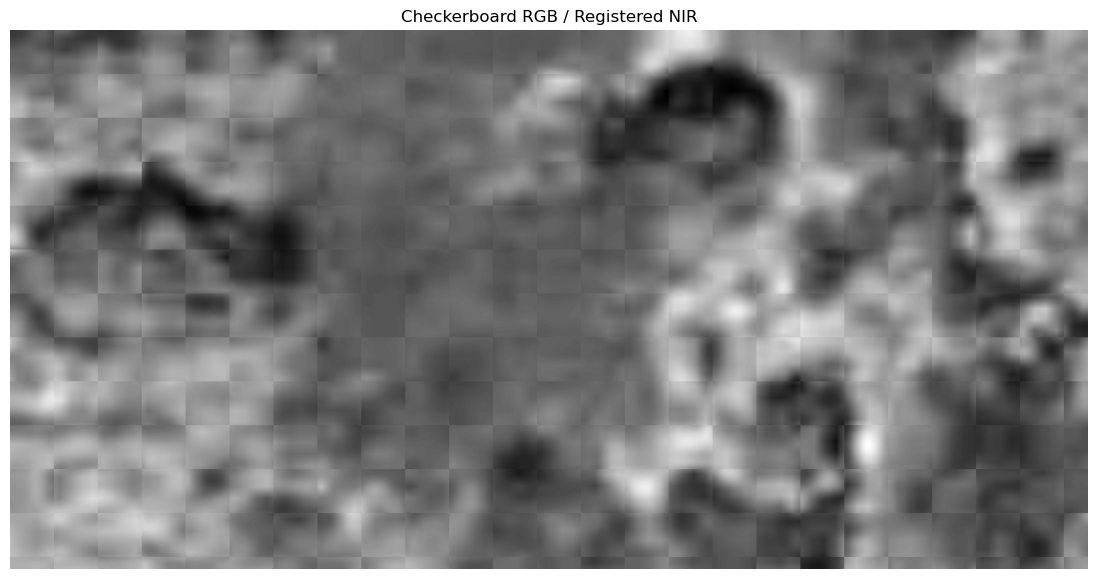

In [51]:
checker = checkerboard_images(
    rgb_vis,
    nir_after_vis,
    block_size=80
)

plt.figure(figsize=(14, 7))
plt.imshow(checker, cmap="gray")
plt.title("Checkerboard RGB / Registered NIR")
plt.axis("off")
plt.show()